# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sys
import astropy.constants as cst
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation

import jax
import jax.numpy as jnp

In [2]:
import fisher_matrix_analysis as fma
import jax_optimizer as opt_jax

/home/cl-a-millard/venvs/jupyter/lib/python3.14/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
# figure size setting for article

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.sans-serif": "Computer Modern Roman",
    "figure.dpi": 300,
    "figure.figsize": (6.1,4.6),  # Put your journal width here
    "savefig.bbox": "tight"})

In [4]:
z_roman = np.array([0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475,
       0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875, 0.925,
       0.975, 1.025, 1.075, 1.125, 1.175, 1.225, 1.275, 1.325, 1.375,
       1.425, 1.475, 1.525, 1.575, 1.625, 1.675, 1.725, 1.775, 1.825,
       1.875, 1.925, 1.975, 2.025, 2.075, 2.125, 2.175, 2.225, 2.275,
       2.325, 2.375, 2.425, 2.475, 2.525, 2.575, 2.625, 2.675, 2.725,
       2.775, 2.825, 2.875, 2.925, 2.975])

z_edges = np.array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 ,
       1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65,
       1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 ,
       2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 , 2.75,
       2.8 , 2.85, 2.9 , 2.95, 3.  ])


# Optimization from fake vs original

In [5]:
upper_bound = np.load('SNIa_count.npz')
NIa_tot = upper_bound['NIa_tot']

In [7]:
# load optimization from original results
info = np.load("dist_roman_original.npz")
dist_original= info['dist']
FOM_original= info['FOM']
FF_original = info['FF']
Cov_stat_original = info['Cov_stat']
Cov_sys = info['Cov_sys']

track_data = np.load("results/optimization_tracks_jax25000_fCPL.npz")

track_FOM = track_data["track_FOM"]
track_FF = track_data["track_FF"]
track_distribution = track_data["track_distribution"]
track_delta_n = track_data["track_delta_n"]
track_dFOM = track_data["track_dFOM"]
track_kk = track_data["track_kk"]
optimized_dist = track_distribution[-1]

print("All tracking arrays successfully loaded")


All tracking arrays successfully loaded


In [9]:
# load optimization from fake results
info_fake = np.load("dist_roman_fake.npz")
dist_fake = info_fake['dist']
FOM_fake = info_fake['FOM']
FF_fake = info_fake['FF']
Cov_stat_fake = info_fake['Cov_stat'] # Cov_sys similar for all

track_data_fake = np.load("results/optimization_tracks_jax25000_fake.npz")

track_FOM_fake = track_data_fake["track_FOM"]
track_FF_fake = track_data_fake["track_FF"]
track_distribution_fake = track_data_fake["track_distribution"]
track_delta_n_fake = track_data_fake["track_delta_n"]
track_dFOM_fake = track_data_fake["track_dFOM"]
track_kk_fake = track_data_fake["track_kk"]
optimized_dist_fake = track_distribution[-1]

print("All tracking arrays successfully loaded")


All tracking arrays successfully loaded


In [10]:
# load optimization from fake_nolowz results
info_fake_nolowz = np.load("dist_roman_fake_nolowz.npz")
dist_fake_nolowz = info_fake_nolowz['dist']
FOM_fake_nolowz = info_fake_nolowz['FOM']
FF_fake_nolowz = info_fake_nolowz['FF']
Cov_stat_fake_nolowz = info_fake_nolowz['Cov_stat'] # Cov_sys similar for all

track_data_fake_nolowz = np.load("results/optimization_tracks_jax25000_fake_nolowz.npz")

track_FOM_fake_nolowz = track_data_fake_nolowz["track_FOM"]
track_FF_fake_nolowz = track_data_fake_nolowz["track_FF"]
track_distribution_fake_nolowz = track_data_fake_nolowz["track_distribution"]
track_delta_n_fake_nolowz = track_data_fake_nolowz["track_delta_n"]
track_dFOM_fake_nolowz = track_data_fake_nolowz["track_dFOM"]
track_kk_fake_nolowz = track_data_fake_nolowz["track_kk"]
optimized_dist_fake_nolowz = track_distribution[-1]

print("All tracking arrays successfully loaded")


All tracking arrays successfully loaded


In [11]:
# FOM improvement

#FOM_original = np.load('FOM_original.npz')['arr_0']
# print("Original figure or merit:",FOM_original)
# print("Original fake figure or merit:",FOM_fake)

FOM_opt = track_FOM[-1]
FOM_opt_fake = track_FOM_fake[-1]

# print('FOM ratio new/ref original', FOM_opt/FOM_original)
# print('FOM ratio new/ref fake', FOM_opt_fake/FOM_fake)

fom_improvement = (FOM_opt - FOM_original) / FOM_original * 100
print('FOM improvement from original distribution:', fom_improvement, '%')

fom_improvement_fake = (FOM_opt_fake - FOM_fake) / FOM_fake * 100
print('FOM improvement from fake distribution:', fom_improvement_fake, '%')

print("Optimized original figure or merit:",FOM_opt)
print("Optimized fake figure or merit:",FOM_opt_fake)

FOM improvement from original distribution: 20.650900689003475 %
FOM improvement from fake distribution: 844.3040989957769 %
Optimized original figure or merit: 49.377247601503754
Optimized fake figure or merit: 49.78537074570137


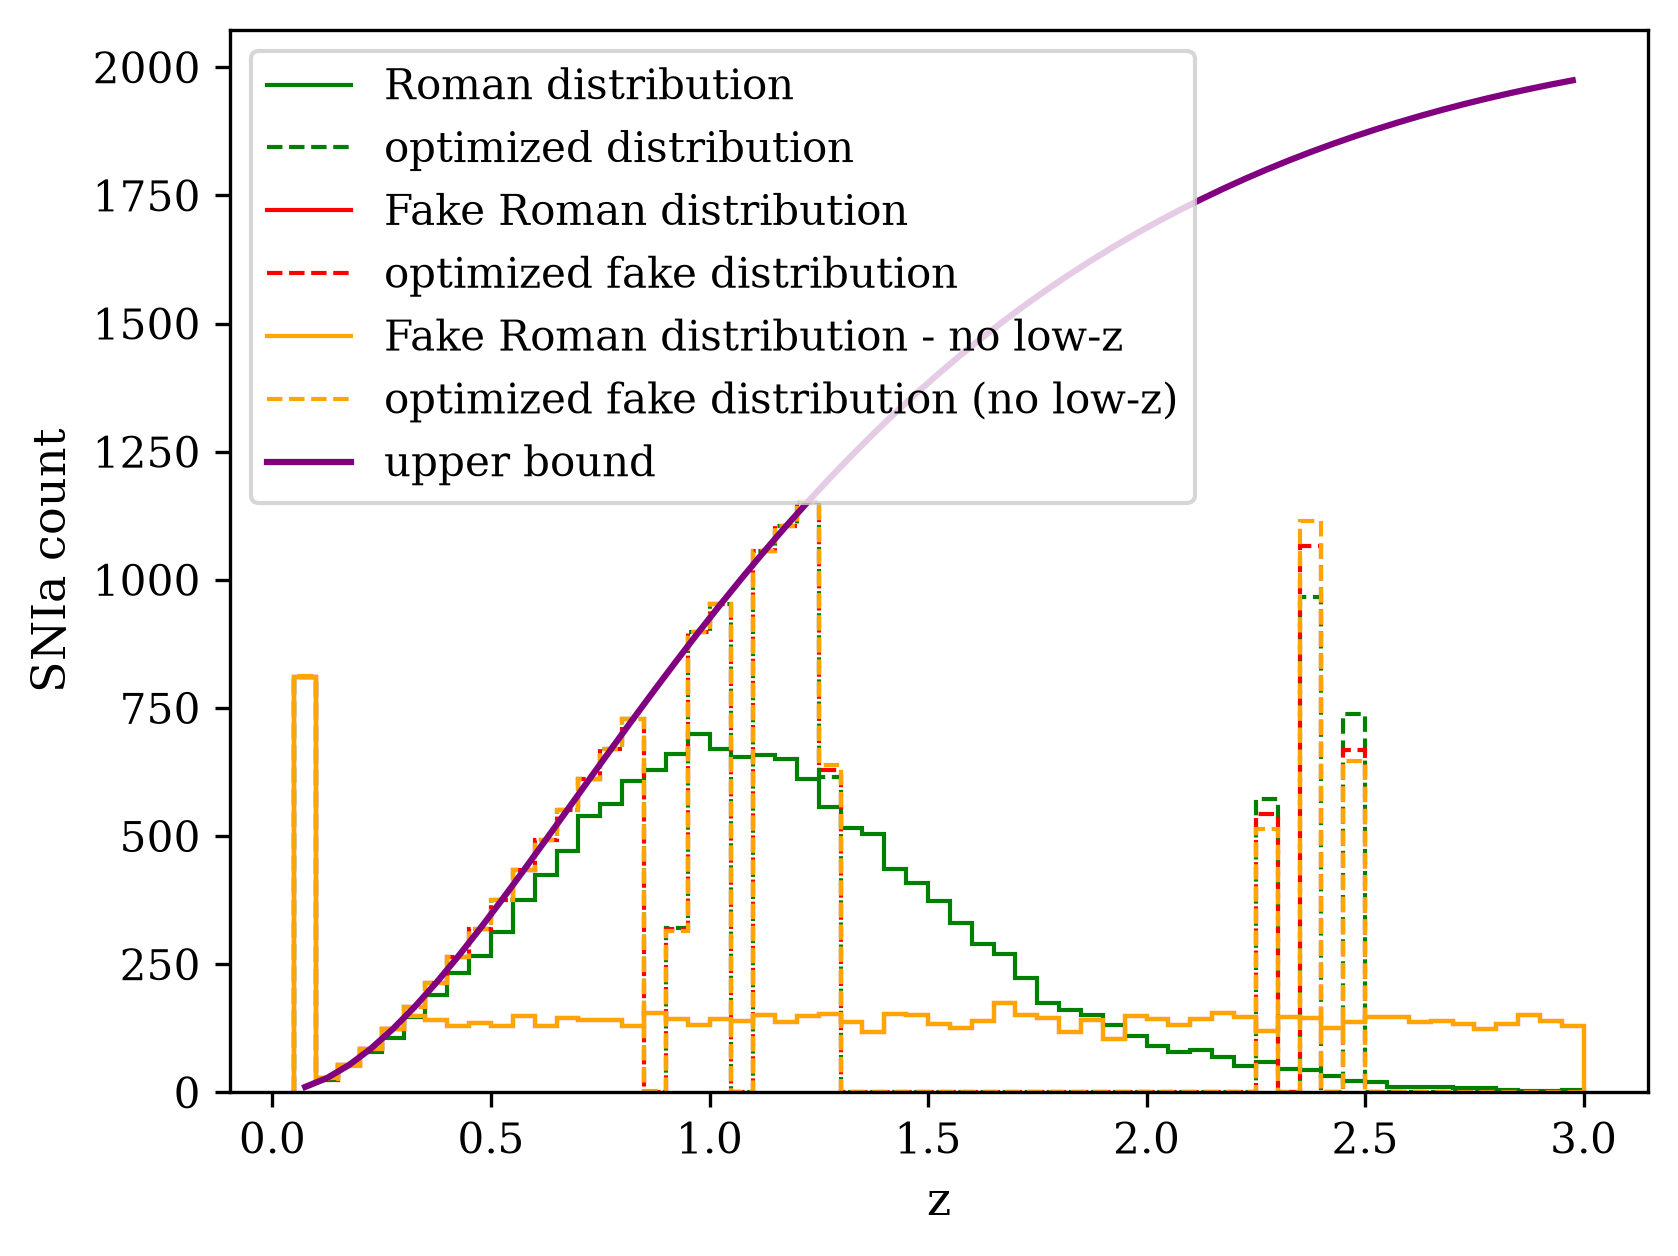

In [12]:


# # original
plt.stairs(dist_original, z_edges, label="Roman distribution", color="green")
#plt.stairs(track_distribution[150], z_edges, label='at convergence', color='blue', ls='--')
plt.stairs(track_distribution[-1], z_edges, label='optimized distribution', color='green', ls='--')

# fake
plt.stairs(dist_fake, z_edges, label="Fake Roman distribution", color="red")
plt.stairs(track_distribution_fake[-1], z_edges, label='optimized fake distribution', color='red', ls='--')

# fake
plt.stairs(dist_fake_nolowz, z_edges, label="Fake Roman distribution - no low-z", color="orange")
plt.stairs(track_distribution_fake_nolowz[-1], z_edges, label='optimized fake distribution (no low-z)', color='orange', ls='--')

plt.plot(z_roman, NIa_tot, color='purple', label='upper bound')

plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper left')
plt.savefig('figures/roman_dist_25000')
plt.show()

Text(0, 0.5, 'FOM')

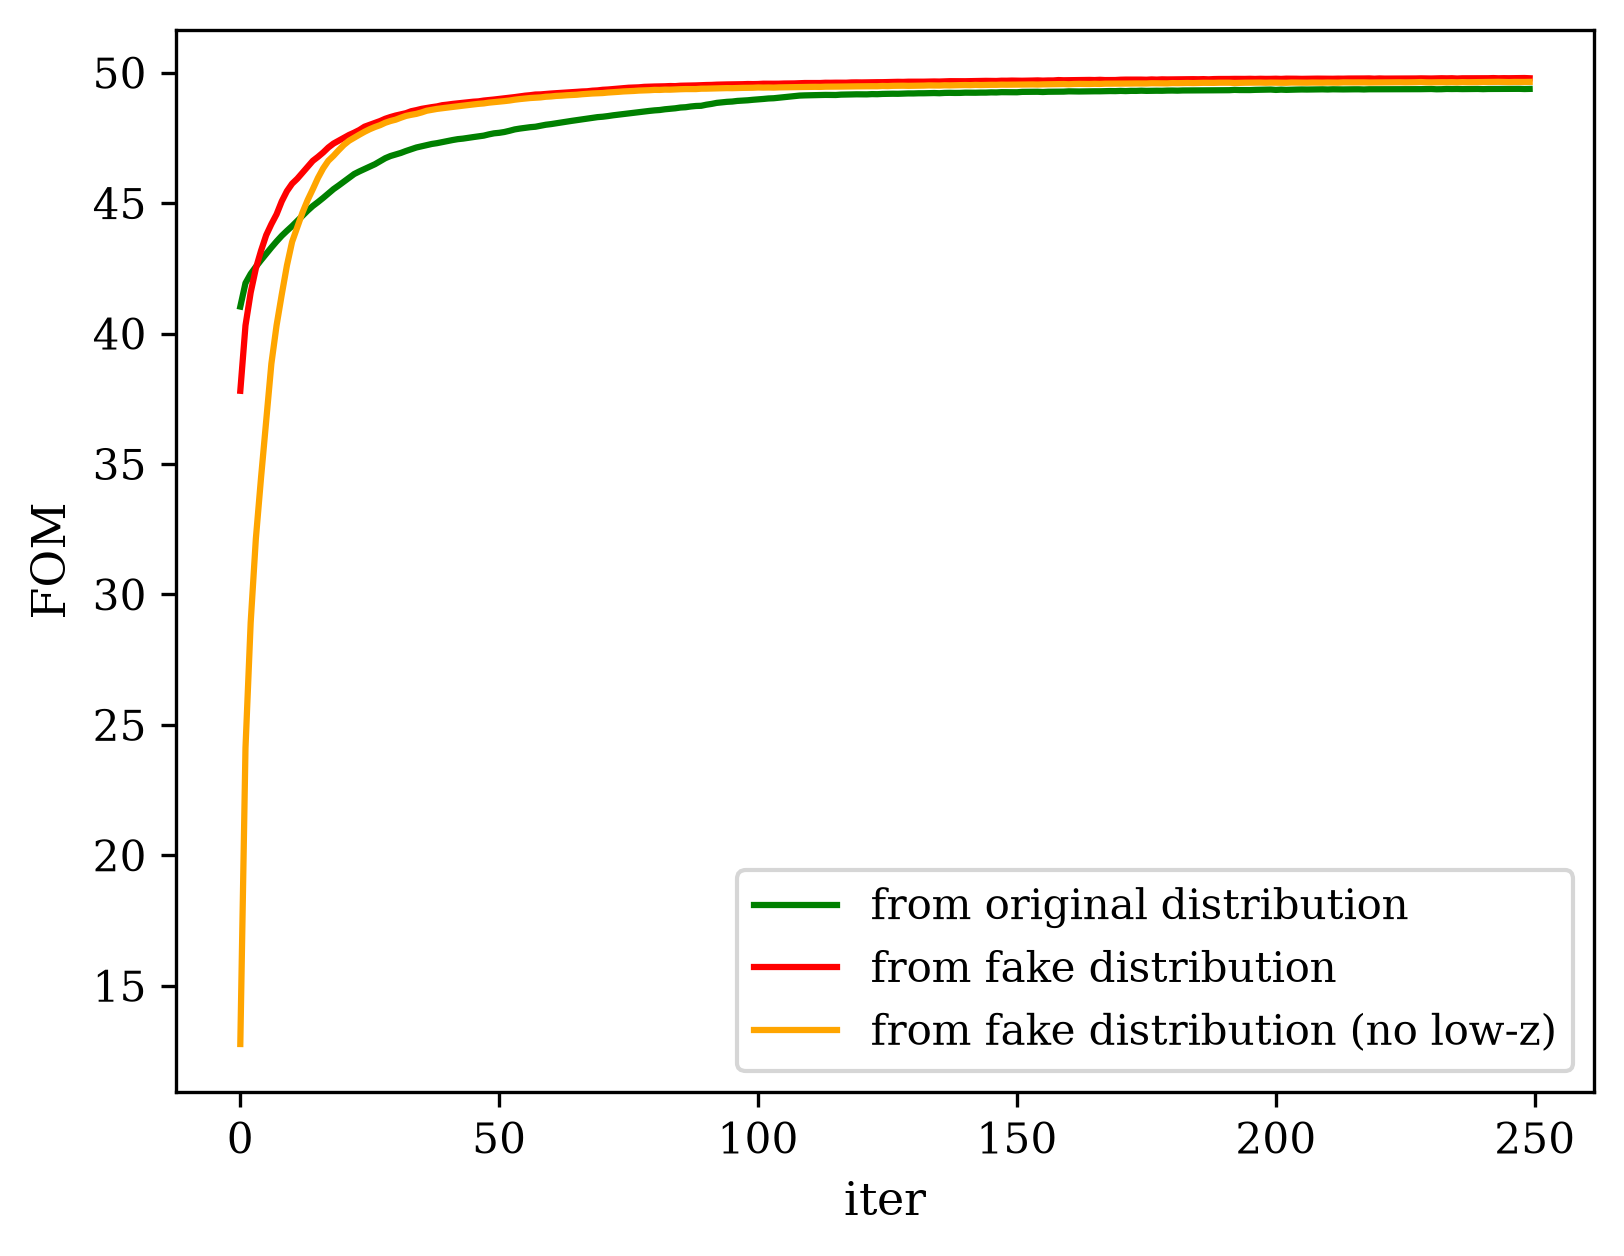

In [13]:
plt.plot(track_FOM, color='green', label='from original distribution')
plt.plot(track_FOM_fake, color='red', label='from fake distribution')
plt.plot(track_FOM_fake_nolowz, color='orange', label='from fake distribution (no low-z)')
plt.legend()
plt.xlabel('iter')
plt.ylabel('FOM')

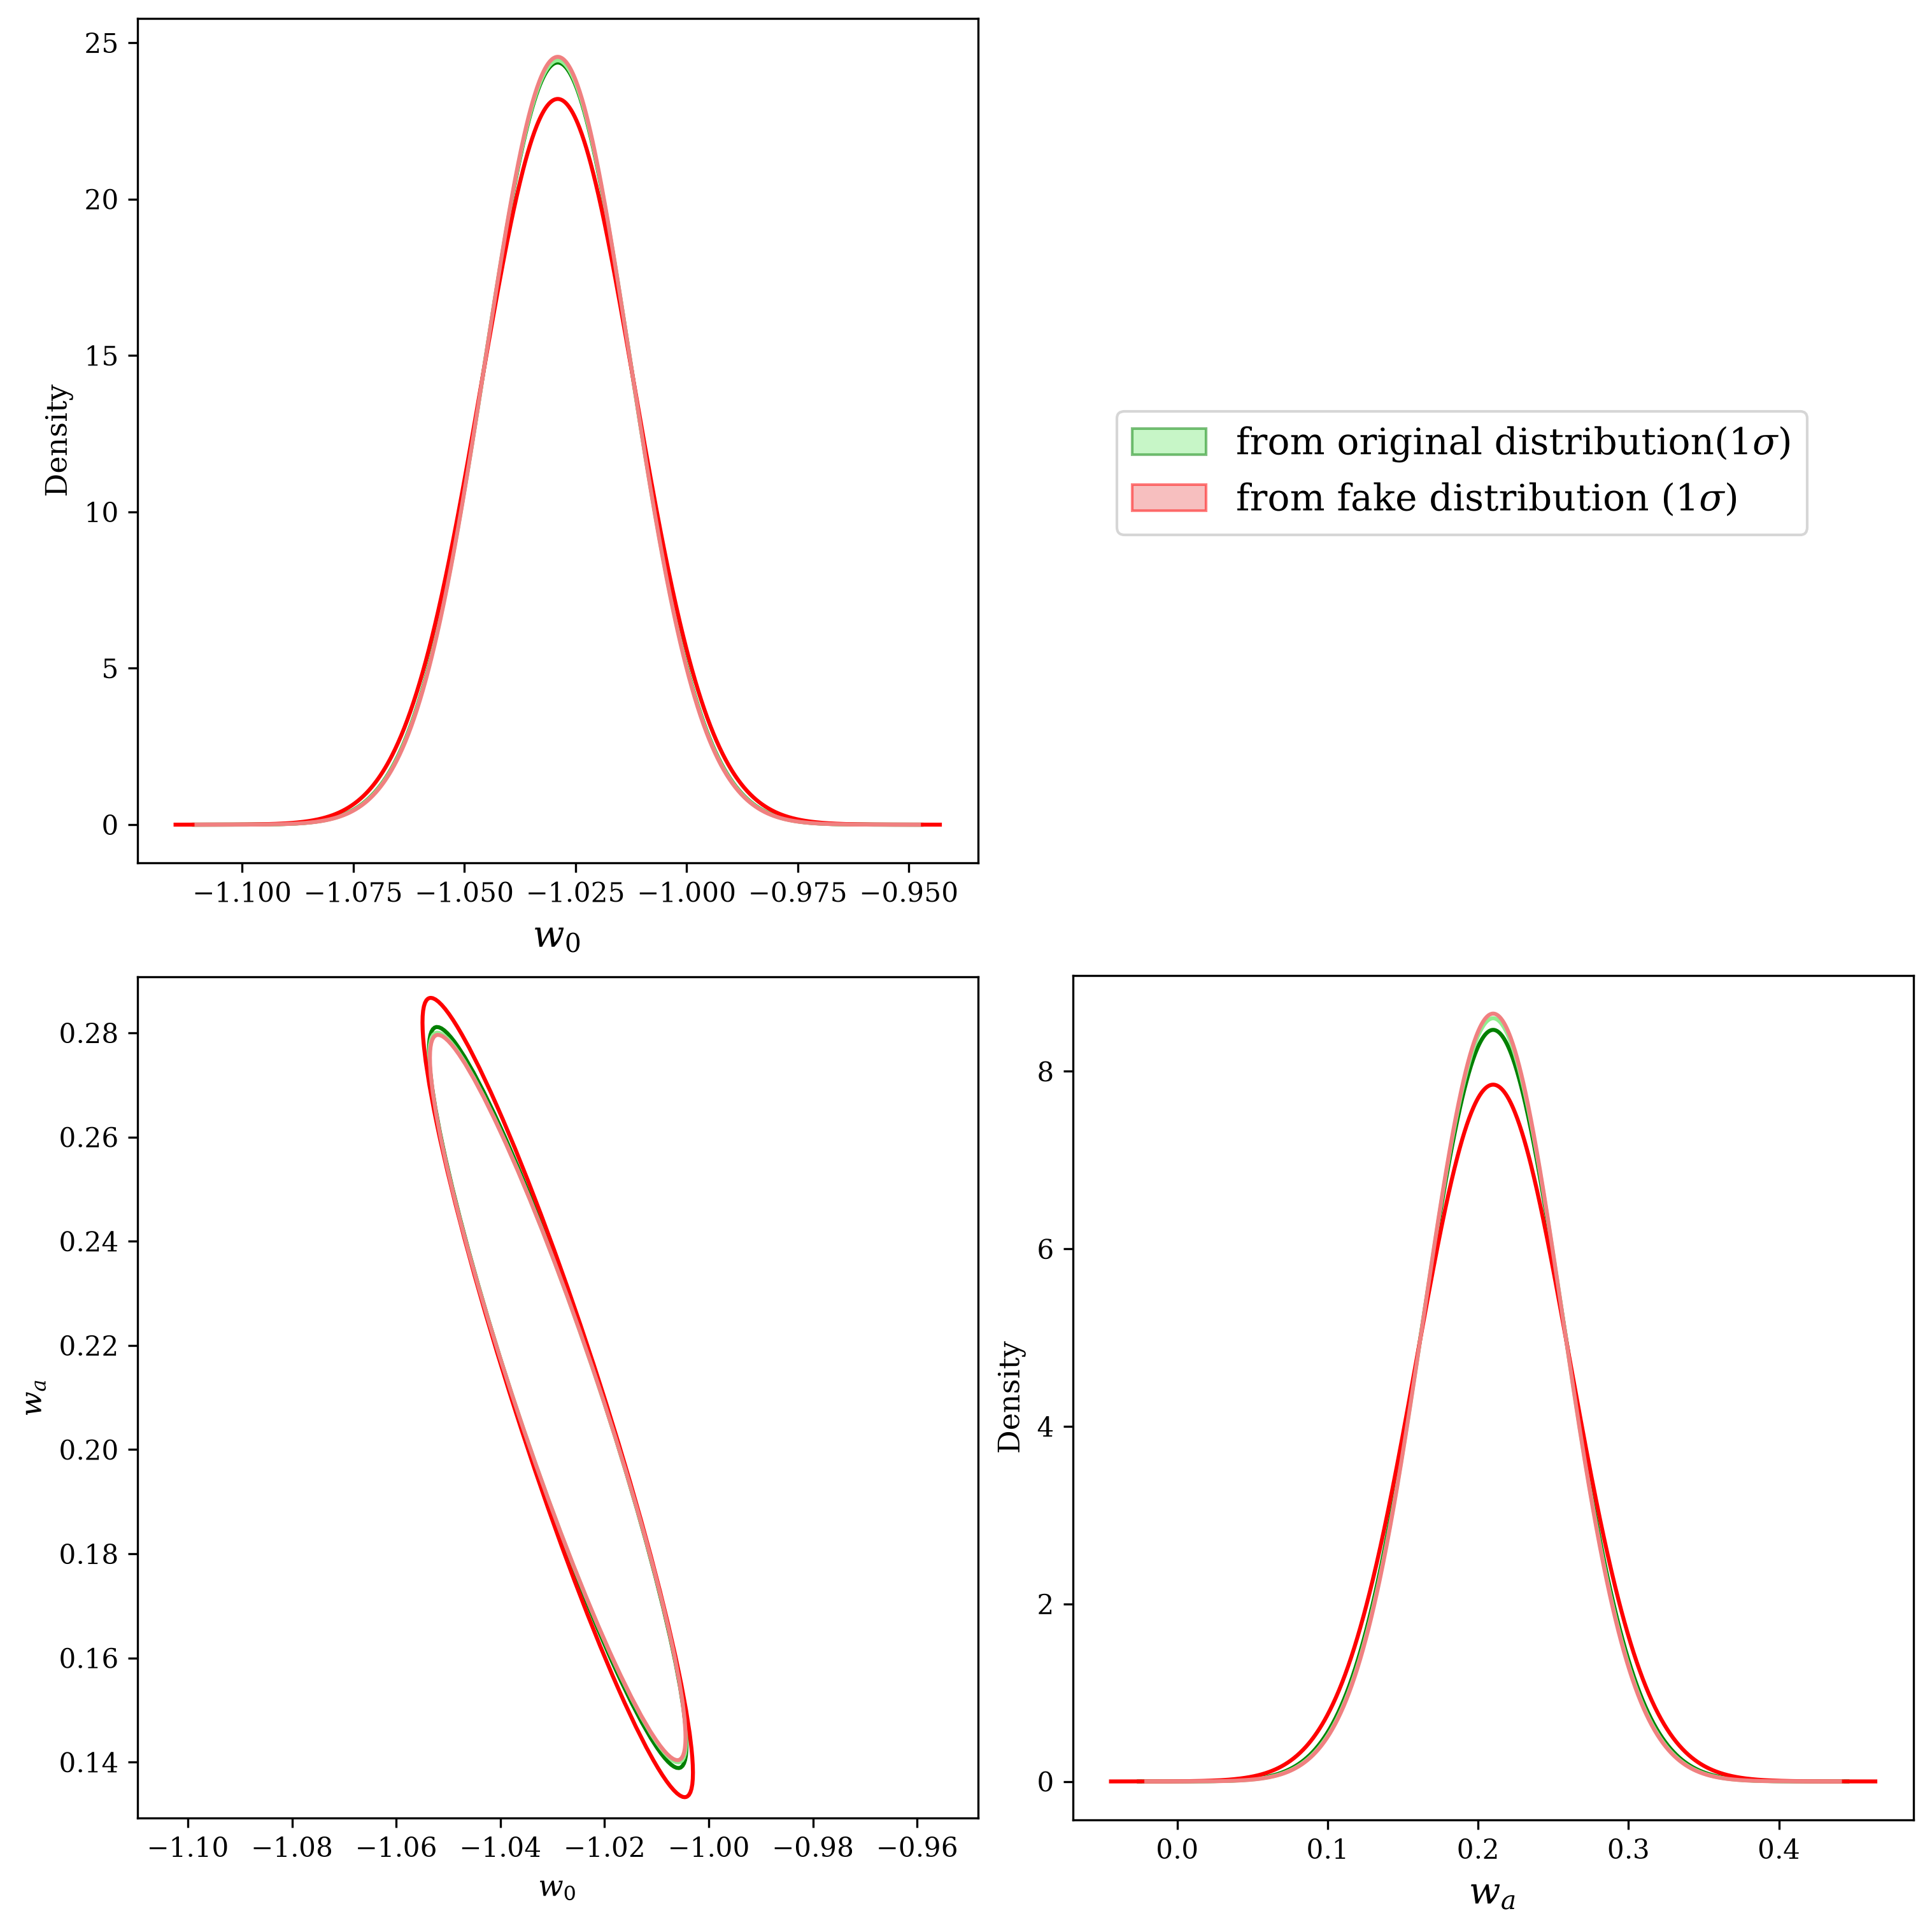

In [14]:
#for flat CPL

Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21
H0_fid=73
Mb_fid=-19.3

fiducial_fCPL=[Om0_fCPL,w0_fCPL,wa_fCPL,Mb_fid]
param_names = ['w0', 'wa']
param_labels = [r'$w_0$', r'$w_a$']
param_to_plot = ['w0', 'wa']
fiducial_param = [w0_fCPL, wa_fCPL]

fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)

# original fisher matrix
fma.add_fisher_to_plot(
        FF_original,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='green',
        filled=False,
        param_labels=param_labels
    )

# optimised fisher matrix from original distribution
fma.add_fisher_to_plot(
        track_FF[-1],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='lightgreen',
        filled=False,
        param_labels=param_labels
    )

# fake fisher matrix
fma.add_fisher_to_plot(
        FF_fake,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        param_labels=param_labels
    )

# optimised fisher matrix from fake distribution
fma.add_fisher_to_plot(
        track_FF_fake[-1],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='lightcoral',
        filled=False,
        param_labels=param_labels
    )

# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='green', alpha=0.5, label=r'from original distribution(1$\sigma$)'),
    Patch(facecolor='lightcoral', edgecolor='red', alpha=0.5, label=r'from fake distribution (1$\sigma$)'),
    #Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'Iteration 5000(1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
#plt.savefig('figures/ellispes_comparison_roman_25000')
# Show the final overlaid plot
plt.show()

In [ ]:
FF_fake

array([[ 28525.72170027,   9061.5774206 ,   1716.76768856,
        -21285.62267318],
       [  9061.5774206 ,   3265.76530865,    576.59648273,
         -6677.46227602],
       [  1716.76768856,    576.59648273,    112.8199237 ,
         -1085.76595806],
       [-21285.62267318,  -6677.46227602,  -1085.76595806,
         26687.56647476]])